# Recreation of `matlab` script from Cael

In [5]:
# import base packages for data analysis
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import xesmf as xe
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from scipy.stats import genextreme, describe
from astropy.stats import kuiper, kuiper_two

# import custom stuff
from ambpy.plotutils import make_figure_filename
plt.style.use('ambpy')

# set random attributes
np.random.seed(4)

save_figs = False

In [52]:
ds_max = xr.open_dataset('data/ERA5/landonly/era5_t2m_annual_max_1deg_landonly.nc')
ds_mean = xr.open_dataset('data/ERA5/landonly/era5_t2m_annual_mean_1deg_landonly.nc')

In [3]:
ds_max

<xarray.Dataset> Size: 39MB
Dimensions:   (year: 75, lat: 180, lon: 360)
Coordinates:
  * lat       (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon       (lon) int64 3kB 0 1 2 3 4 5 6 7 ... 353 354 355 356 357 358 359
  * year      (year) int64 600B 1950 1951 1952 1953 1954 ... 2021 2022 2023 2024
Data variables:
    t2m       (year, lat, lon) float32 19MB ...
    t2m_anom  (year, lat, lon) float32 19MB ...

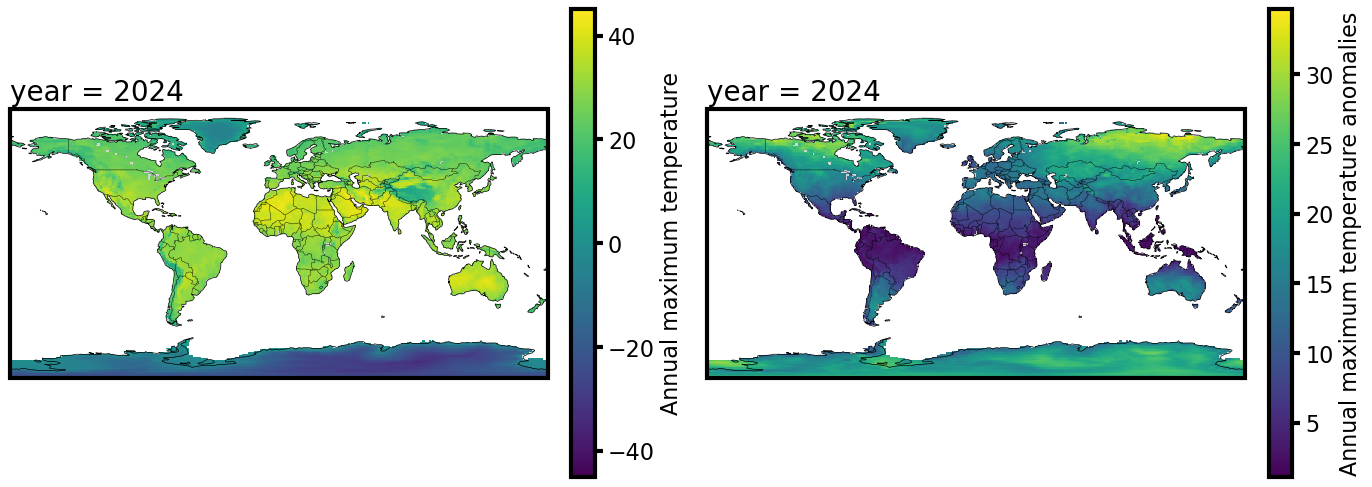

In [49]:
# check plot of annual max (raw) and annual max (anomalies)
YEAR = 2024
das = [ds_max['t2m'].sel(year=YEAR) - 273.3, ds_max['t2m_anom'].sel(year=YEAR)]
varss = ['Annual maximum temperature', 'Annual maximum temperature anomalies']

# --- Create the map ---
fig, axes = plt.subplots(
    nrows=1, ncols=2,
    figsize=(14, 12),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

for ax, da, var in zip(axes.flat, das, varss):
    # Add geographic features
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.add_feature(cfeature.LAND, facecolor="lightgray")
    ax.add_feature(cfeature.OCEAN, facecolor="white")

    im = da.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap='viridis',
        add_colorbar=False
    )
    cbar = fig.colorbar(im, ax=ax, orientation='vertical',
                        fraction=0.04, pad=0.04)
    cbar.set_label(var)

# --- Plot data ---
# Show or save
plt.tight_layout()
if save_figs:
    plt.savefig(make_figure_filename('t2m-t2m_anom-sanity',
                                     'png', 'figs/'))
plt.show()

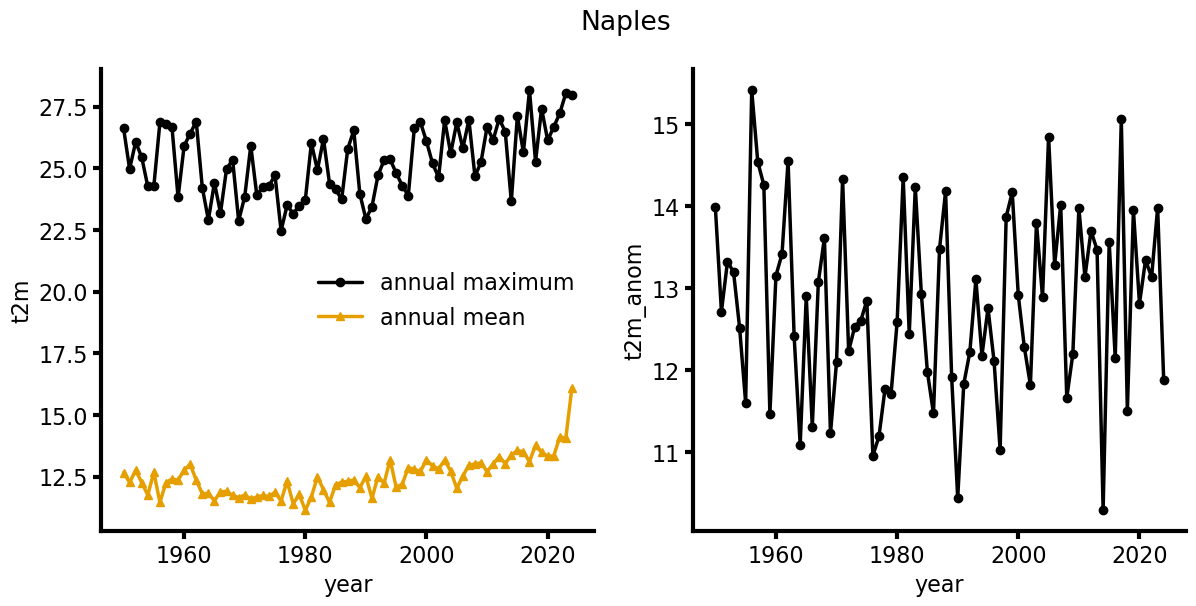

In [59]:
# sanity check 2: at a particular location
naples = (41, 14)  # N, E
astana = (50, 70)  # N, E
tucson = (32, 110)  # N, W
brisbane = (27, 153)  # S, E

lat, lon = naples

da_raw = ds_max['t2m'].sel(lat=lat,
                           lon=lon,
                           method='nearest') - 273.3

da_mean = ds_mean['t2m'].sel(lat=lat,
                             lon=lon,
                             method='nearest') - 273.3

da_anom = ds_max['t2m_anom'].sel(lat=lat, 
                                 lon=lon, 
                                 method='nearest')

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
da_raw.plot(ax=ax[0], marker='o', label='annual maximum')
da_mean.plot(ax=ax[0], marker='^', label='annual mean')
da_anom.plot(ax=ax[1], marker='o')
fig.suptitle('Naples')
ax[0].legend()

for ax in ax.flat:
    ax.set_title('')

# Take multidecadal trend and subtract from annual maxima

In [60]:
ds_max

<xarray.Dataset> Size: 39MB
Dimensions:   (year: 75, lat: 180, lon: 360)
Coordinates:
  * lat       (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon       (lon) int64 3kB 0 1 2 3 4 5 6 7 ... 353 354 355 356 357 358 359
  * year      (year) int64 600B 1950 1951 1952 1953 1954 ... 2021 2022 2023 2024
Data variables:
    t2m       (year, lat, lon) float32 19MB ...
    t2m_anom  (year, lat, lon) float32 19MB ...

In [66]:
shape_dum = ds_max['t2m'].sel(year=2000).data
shape_dum[:, :] = -0.25
ds_max.assign(shape_dum=(('lat', 'lon'), shape_dum))

<xarray.Dataset> Size: 39MB
Dimensions:    (year: 75, lat: 180, lon: 360)
Coordinates:
  * lat        (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon        (lon) int64 3kB 0 1 2 3 4 5 6 7 ... 353 354 355 356 357 358 359
  * year       (year) int64 600B 1950 1951 1952 1953 ... 2021 2022 2023 2024
Data variables:
    t2m        (year, lat, lon) float32 19MB ...
    t2m_anom   (year, lat, lon) float32 19MB ...
    shape_dum  (lat, lon) float32 259kB -0.25 -0.25 -0.25 ... -0.25 -0.25 -0.25

In [67]:
x = np.array([1] * 19)
x

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [71]:
ds_max.assign(x=x).x.values

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

# Fitting GEV distributions to the data